# Relationship between bank's Profitability and Liquidity Risk

## Data Preparation

In [357]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [358]:
# Load dataset
# File name
file_path = "dataset_thesis.xlsx"

# Read file
df = pd.read_excel(file_path, sheet_name="bs_rates_ovt")

# Display
df.head()

,period,cash_reserve,interbank_lending,government_bonds,corporate_bonds,government_loans,domestic_loans,total_assets,interbank_lending_rate,government_bonds_rate,...,government_loans_rate,domestic_loans_rate,deposits_overnight,deposits_with_agreed_maturity,deposits_repos,deposits_to_central_government,debt_securities_issued,interbank_borrowing,other_funding,total_liabilities
0,2005-01-01,34481.4,214563.884,93851.2,2654.5,20576.5,247352.5,613479.984,6.276667,5.97,...,6.47,9.63,129701.394,198081.0,7186.789,39776.1,5797.1,56680.964,71417.6,508640.947
1,2005-02-01,39765.0,214348.590,93390.7,2506.7,20290.1,247147.6,617448.690,5.954444,5.73,...,6.23,9.70,135107.970,197251.9,6929.197,36433.7,5777.1,56882.320,72651.3,511033.487
2,2005-03-01,33904.7,212005.547,96831.5,2191.0,21574.5,251358.4,617865.647,5.632222,5.55,...,6.05,9.36,138514.177,201900.4,7272.087,26665.6,6166.7,57254.373,73282.8,511056.137
3,2005-04-01,33471.9,231201.028,92974.1,1979.9,20370.0,259738.6,639735.528,5.310000,5.49,...,5.99,9.21,132440.020,211162.8,8575.093,33390.4,6211.9,58881.946,79578.4,530240.559
4,2005-05-01,30983.2,235563.668,92325.2,2251.9,19127.4,266264.2,646515.568,5.070000,5.35,...,5.85,8.91,146275.041,204489.4,9711.293,34782.9,8104.6,57318.513,74097.0,534778.747


In [359]:
# Set index for time variable
df["period"] = pd.to_datetime(df["period"])
df = df.sort_values("period")

# Create year col
df["year"] = df["period"].dt.year

# Create month col
df["month"] = df["period"].dt.month

In [360]:
# Categorize variables
# Assets
asset_cols = [
    "cash_reserve",
    "interbank_lending",
    "government_bonds",
    "corporate_bonds",
    "government_loans",
    "domestic_loans"
]

# Interest rates
rate_cols = [
    "interbank_lending_rate",
    "government_bonds_rate",
    "corporate_bonds_rate",
    "government_loans_rate",
    "domestic_loans_rate"
]

# Liabilities
liability_cols = [
    "deposits_overnight",
    "deposits_with_agreed_maturity",
    "deposits_repos",
    "deposits_to_central_government",
    "debt_securities_issued",
    "interbank_borrowing",
    "other_funding"
]

In [361]:
# Convert interest rates from percentage to float
df[rate_cols] = df[rate_cols] / 100

In [362]:
# Feature engineering
# Historical assets' weights 
for i, col in enumerate(asset_cols, start=1):
    df[f"w{i}_history"] = df[col] / df["total_assets"]

# Historical ROA
df["roa_history"] = (
    df["w1_history"] * 0 + # cash's rates = 0
    df["w2_history"] * df["interbank_lending_rate"] +
    df["w3_history"] * df["government_bonds_rate"] +
    df["w4_history"] * df["corporate_bonds_rate"] +
    df["w5_history"] * df["government_loans_rate"] +
    df["w6_history"] * df["domestic_loans_rate"]
)

# Historical profit
df["profit_history"] = df["roa_history"] * df["total_assets"]

In [363]:
# Display
df.head()

,period,cash_reserve,interbank_lending,government_bonds,corporate_bonds,government_loans,domestic_loans,total_assets,interbank_lending_rate,government_bonds_rate,...,year,month,w1_history,w2_history,w3_history,w4_history,w5_history,w6_history,roa_history,profit_history
0,2005-01-01,34481.4,214563.884,93851.2,2654.5,20576.5,247352.5,613479.984,0.062767,0.0597,...,2005,1,0.056206,0.349749,0.152982,0.004327,0.033541,0.403196,0.072428,44433.285376
1,2005-02-01,39765.0,214348.590,93390.7,2506.7,20290.1,247147.6,617448.690,0.059544,0.0573,...,2005,2,0.064402,0.347152,0.151253,0.004060,0.032861,0.400272,0.070525,43545.713159
2,2005-03-01,33904.7,212005.547,96831.5,2191.0,21574.5,251358.4,617865.647,0.056322,0.0555,...,2005,3,0.054874,0.343126,0.156719,0.003546,0.034918,0.406817,0.068482,42312.595770
3,2005-04-01,33471.9,231201.028,92974.1,1979.9,20370.0,259738.6,639735.528,0.053100,0.0549,...,2005,4,0.052321,0.361401,0.145332,0.003095,0.031841,0.406009,0.066702,42671.435247
4,2005-05-01,30983.2,235563.668,92325.2,2251.9,19127.4,266264.2,646515.568,0.050700,0.0535,...,2005,5,0.047923,0.364359,0.142804,0.003483,0.029585,0.411845,0.064795,41891.083938


## Exploratory Data Analysis

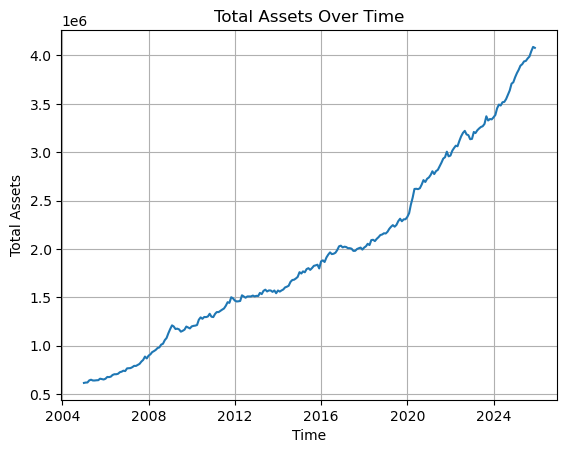

In [365]:
# Total assets overtime
plt.figure()
plt.plot(df["period"], df["total_assets"])
plt.title("Total Assets Over Time")
plt.xlabel("Time")
plt.ylabel("Total Assets")
plt.grid()
plt.show()

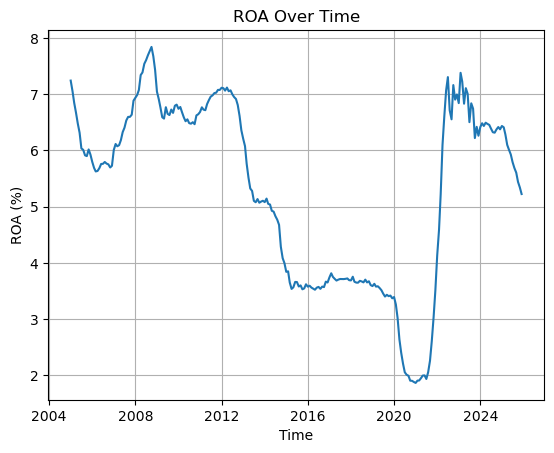

In [366]:
# ROA overtime
plt.figure()
plt.plot(df["period"], df["roa_history"] * 100)
plt.title("ROA Over Time")
plt.xlabel("Time")
plt.ylabel("ROA (%)")
plt.grid()
plt.show()

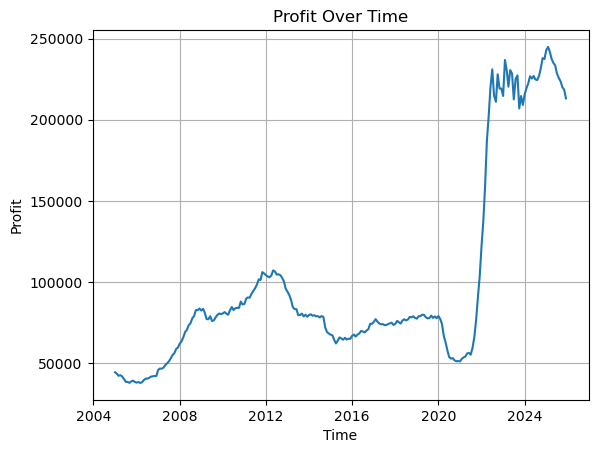

In [367]:
# Profit overtime
plt.figure()
plt.plot(df["period"], df["profit_history"])
plt.title("Profit Over Time")
plt.xlabel("Time")
plt.ylabel("Profit")
plt.grid()
plt.show()

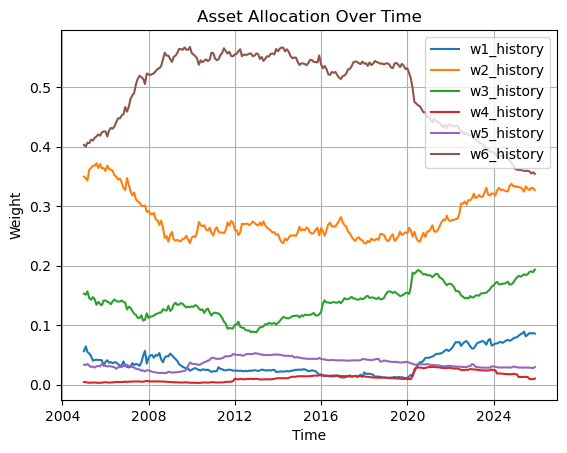

In [368]:
# Assets' weight overtime
w_cols = [f"w{i}_history" for i in range(1, 7)]
plt.figure()

for col in w_cols:
    plt.plot(df["period"], df[col], label=col)

plt.title("Asset Allocation Over Time")
plt.xlabel("Time")
plt.ylabel("Weight")
plt.legend()
plt.grid()
plt.show()

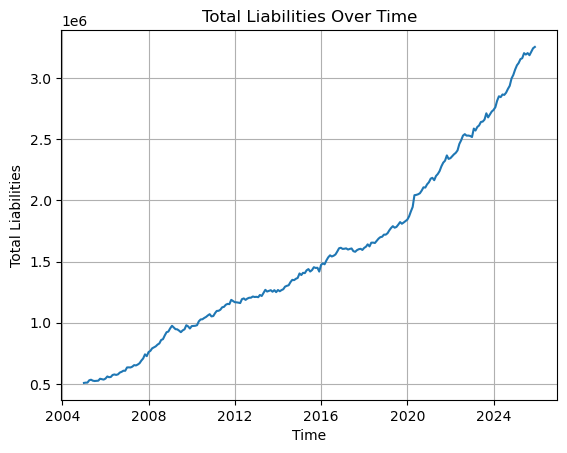

In [369]:
# Total liabilities overtime
plt.figure()
plt.plot(df["period"], df["total_liabilities"])
plt.title("Total Liabilities Over Time")
plt.xlabel("Time")
plt.ylabel("Total Liabilities")
plt.grid()
plt.show()

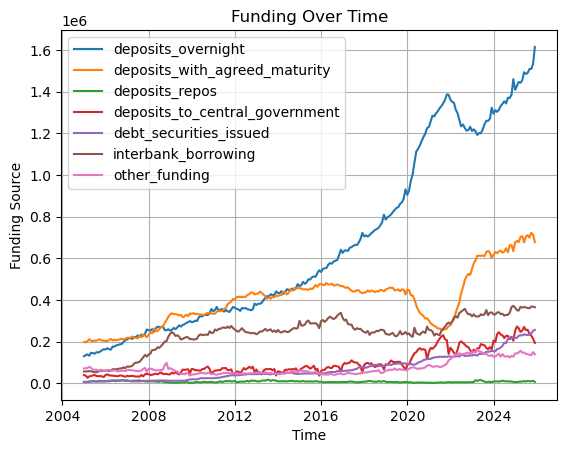

In [370]:
# Funding overtime
plt.figure()

for col in liability_cols:
    plt.plot(df["period"], df[col], label=col)

plt.title("Funding Over Time")
plt.xlabel("Time")
plt.ylabel("Funding Source")
plt.legend()
plt.grid()
plt.show()

## Optimization setup

### Basel's parameters

In [373]:
# Funding runoff rates
runoff_rates = np.array([
    0.5, # deposits overnight
    0.2, # deposits with agreed maturity
    0.4, # deposits repos
    0.6, # deposits to central government
    1.0, # debt securities issued
    1.0, # interbank borrowing
    1.0  # other funding
])

# HQLA weights
hqla_weights = np.array([
    1.0,  # cash
    0.0,  # interbank lending
    1.0,  # government bonds
    0.3,  # corporate bonds
    0.0,  # government loans
    0.0   # domestic loans
])

# Asset inflow rates
inflow_rates = np.array([
    0.0,  # cash
    0.4,  # interbank lending
    0.0,  # government bonds
    0.2,  # corporate bonds
    0.05, # government loans
    0.1   # domestic loans
])

### Config

In [375]:
# Decision variables' bounds
bounds = [
        (0.02, 0.10),
        (0.20, 0.40),
        (0.10, 0.30),
        (0.10, 0.40),
        (0.02, 0.10),
        (0.30, 0.60)
    ]

In [376]:
# Constraint - Sum of assets' weight = 1
constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    ]

In [377]:
config = {
    # fixed
    "runoff_rates": runoff_rates,
    "hqla_weights": hqla_weights,
    "inflow_rates": inflow_rates,
    "bounds": bounds,
    "constraints": constraints,
    
    # stochastic
    "runoff_vol": np.array([0.05, 0.05, 0.1, 0.1, 0.2, 0.2, 0.2]),
    "n_scenarios": 1000
}

### Deterministic

In [379]:
# Deterministic
def build_model_deterministic(state):
    
    total_assets = state["total_assets"]
    liabilities = state["liabilities"]
    returns = state["returns"]
    
    n = len(returns)

    def roa(w):
        return np.dot(w, returns)

    def compute_hqla(w):
        return np.dot(w, hqla_weights) * total_assets

    def compute_outflows():
        return np.dot(liabilities, runoff_rates)

    def compute_inflows(w):
        return np.dot(w, inflow_rates) * total_assets

    def compute_net_outflows(w):
        outflows = compute_outflows()
        inflows = compute_inflows(w)
        capped_inflows = min(inflows, 0.75 * outflows)
        return outflows - capped_inflows

    def lcr(w):
        net_outflows = compute_net_outflows(w)
        if net_outflows <= 0:
            return 1e6
        return compute_hqla(w) / net_outflows

    def solve_single_objective(obj_func, maximize=True):
        func = (lambda w: -obj_func(w)) if maximize else obj_func
        w0 = np.ones(n) / n
        
        res = minimize(func, w0, bounds=bounds, constraints=constraints)
        
        return -res.fun if maximize else res.fun

    roa_max = solve_single_objective(roa, True)
    roa_min = solve_single_objective(roa, False)
    
    lcr_max = solve_single_objective(lcr, True)
    lcr_min = solve_single_objective(lcr, False)

    def roa_norm(w):
        return (roa(w) - roa_min) / (roa_max - roa_min)

    def lcr_norm(w):
        return (lcr(w) - lcr_min) / (lcr_max - lcr_min)

    def objective(w, alpha=0.5):
        return - (alpha * roa_norm(w) + (1 - alpha) * lcr_norm(w))

    def optimize(alpha=0.5):
        w0 = np.ones(n) / n
        
        res = minimize(
            lambda w: objective(w, alpha),
            w0,
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            options={'maxiter': 500}
        )
        
        return res

    return {
        "roa": roa,
        "lcr": lcr,
        "optimize": optimize,
    }

### Stochastic

In [381]:
def generate_runoff_scenarios(runoff_rates, runoff_vol, n_scenarios):
    
    n_liab = len(runoff_rates)
    scenarios = np.zeros((n_scenarios, n_liab))
    
    for i in range(n_liab):
        shocks = np.random.normal(0, runoff_vol[i], n_scenarios)
        shocks = np.clip(shocks, -0.3, 0.5)
        
        s = runoff_rates[i] * (1 + shocks)
        s *= runoff_rates[i] / np.mean(s)
        
        scenarios[:, i] = s
    
    return scenarios

In [382]:
def build_model_stochastic(state, config):
    
    total_assets = state["total_assets"]
    liabilities = state["liabilities"]
    
    returns_mean = state["returns"]
    returns_cov = state["returns_cov"]
    
    n = len(returns_mean)

    runoff_rates = config["runoff_rates"]
    hqla_weights = config["hqla_weights"]
    inflow_rates = config["inflow_rates"]
    
    bounds = config["bounds"]
    constraints = config["constraints"]
    
    runoff_vol = config["runoff_vol"]
    n_scenarios = config["n_scenarios"]

    # ===== SCENARIOS =====
    
    runoff_scenarios = generate_runoff_scenarios(
        runoff_rates, runoff_vol, n_scenarios
    )
    
    returns_scenarios = np.random.multivariate_normal(
        returns_mean,
        returns_cov,
        size=n_scenarios
    )

    # ===== CORE =====
    
    def roa_scenario(w, s):
        return np.dot(w, returns_scenarios[s])

    def expected_roa(w):
        return np.mean([roa_scenario(w, s) for s in range(n_scenarios)])

    def lcr_scenario(w, s):
        
        hqla = np.dot(w, hqla_weights) * total_assets
        
        outflows = np.dot(liabilities, runoff_scenarios[s])
        inflows = np.dot(w, inflow_rates) * total_assets
        
        capped = min(inflows, 0.75 * outflows)
        net = outflows - capped
        
        return hqla / net if net > 0 else 1e6

    def expected_lcr(w):
        return np.mean([lcr_scenario(w, s) for s in range(n_scenarios)])

    def worst_lcr(w):
        vals = [lcr_scenario(w, s) for s in range(n_scenarios)]
        return np.percentile(vals, 5)

    def prob_lcr_breach(w):
        vals = [lcr_scenario(w, s) for s in range(n_scenarios)]
        return np.mean(np.array(vals) < 1)

    # ===== NORMALIZATION =====
    
    def solve(obj, maximize=True):
        func = (lambda w: -obj(w)) if maximize else obj
        
        res = minimize(
            func,
            np.ones(n)/n,
            bounds=bounds,
            constraints=constraints
        )
        
        return -res.fun if maximize else res.fun

    roa_max, roa_min = solve(expected_roa, True), solve(expected_roa, False)
    lcr_max, lcr_min = solve(expected_lcr, True), solve(expected_lcr, False)

    def roa_norm(w):
        return (expected_roa(w) - roa_min) / (roa_max - roa_min)

    def lcr_norm(w):
        return (expected_lcr(w) - lcr_min) / (lcr_max - lcr_min)

    # ===== OBJECTIVE =====
    
    def objective(w, alpha=0.5):
        return -(alpha * roa_norm(w) + (1-alpha) * lcr_norm(w))

    def optimize(alpha=0.5):
        return minimize(
            lambda w: objective(w, alpha),
            np.ones(n)/n,
            bounds=bounds,
            constraints=constraints
        )

    return {
        "expected_roa": expected_roa,
        "expected_lcr": expected_lcr,
        "worst_lcr": worst_lcr,
        "prob_lcr_breach": prob_lcr_breach,
        "optimize": optimize
    }

## State generator

In [384]:
def build_state_from_df(df_input):
    
    mean_vals = df_input.mean()
    
    asset_values = np.array([
        mean_vals["cash_reserve"],
        mean_vals["interbank_lending"],
        mean_vals["government_bonds"],
        mean_vals["corporate_bonds"],
        mean_vals["government_loans"],
        mean_vals["domestic_loans"]
    ])
    
    total_assets = mean_vals["total_assets"]
    
    state = {
        "total_assets": total_assets,
        "asset_values": asset_values,  
        
        "liabilities": np.array([
            mean_vals["deposits_overnight"],
            mean_vals["deposits_with_agreed_maturity"],
            mean_vals["deposits_repos"],
            mean_vals["deposits_to_central_government"],
            mean_vals["debt_securities_issued"],
            mean_vals["interbank_borrowing"],
            mean_vals["other_funding"]
        ]),
        
        "returns": np.array([
            0.0,
            mean_vals["interbank_lending_rate"],
            mean_vals["government_bonds_rate"],
            mean_vals["corporate_bonds_rate"],
            mean_vals["government_loans_rate"],
            mean_vals["domestic_loans_rate"]
        ])
    }
    
    return state

In [385]:
def compute_realistic_weights(state):
    
    asset_values = state["asset_values"]
    total_assets = state["total_assets"]
    
    w = asset_values / total_assets
    
    # normalize (safety)
    w = w / np.sum(w)
    
    return w

In [386]:
def compute_return_statistics(df_input):
    
    # ===== Mean =====
    mean_vals = df_input[rate_cols].mean().values
    
    # ===== Std =====
    std_vals = df_input[rate_cols].std().values
    
    # ===== Covariance =====
    cov_matrix = df_input[rate_cols].cov().values
    
    # ===== Add cash (0 return, 0 vol) =====
    mean_full = np.insert(mean_vals, 0, 0.0)
    std_full = np.insert(std_vals, 0, 0.0)
    
    cov_full = np.zeros((len(mean_full), len(mean_full)))
    cov_full[1:, 1:] = cov_matrix
    
    return mean_full, std_full, cov_full

In [387]:
def build_full_state(df_mean, df_vol):
    
    # ===== STATE =====
    state = build_state_from_df(df_mean)
    
    # ===== RETURN STATISTICS =====
    ret_mean, ret_std, ret_cov = compute_return_statistics(df_vol)
    
    # override mean 
    state["returns"] = ret_mean
    
    # add stochastic params
    state["returns_std"] = ret_std
    state["returns_cov"] = ret_cov
    
    return state

In [388]:
def extract_baseline_report(state, config, w=None):
    
    total_assets = state["total_assets"]
    liabilities = state["liabilities"]
    returns = state["returns"]
    
    runoff_rates = config["runoff_rates"]
    hqla_weights = config["hqla_weights"]
    inflow_rates = config["inflow_rates"]
    
    n = len(returns)
    
    # ===== DEFAULT WEIGHTS  =====
    if w is None:
        w = compute_realistic_weights(state)
    
    asset_values = w * total_assets
    
    hqla = np.dot(w, hqla_weights) * total_assets
    outflows = np.dot(liabilities, runoff_rates)
    
    inflows = np.dot(w, inflow_rates) * total_assets
    capped_inflows = min(inflows, 0.75 * outflows)
    
    net_outflows = outflows - capped_inflows
    
    lcr_value = hqla / net_outflows if net_outflows > 0 else np.nan
    
    return {
        "weights": w,
        "HQLA": hqla,
        "outflows": outflows,
        "inflows": inflows,
        "LCR": lcr_value,
        "return": np.dot(w, returns)
    }

## Pareto frontier generator

In [390]:
# Testing multiple alphas
def run_pareto(model, alphas=np.linspace(0, 1, 100),
               roa_key="roa", lcr_key="lcr",
               include_prob=False):
    
    results = []
    
    for alpha in alphas:
        
        res = model["optimize"](alpha)
        
        if res.success:
            w = res.x
            
            row = {
                "alpha": alpha,
                "roa": model[roa_key](w),
                "lcr": model[lcr_key](w),
                "weights": w
            }
            
            # optional stochastic metrics
            if include_prob and "prob_lcr_breach" in model:
                row["prob_breach"] = model["prob_lcr_breach"](w)
            
            results.append(row)
        
        else:
            print(f"Optimization failed at alpha={alpha}")
    
    df_results = pd.DataFrame(results)
    
    df_results = df_results.sort_values("lcr")
    
    return df_results

In [391]:
# Plotting Pareto frontier
def plot_pareto(df, label=None, show_alpha=False, color_by=None):
    
    if color_by is None:
        plt.plot(df["lcr"], df["roa"], marker='o', label=label)
    else:
        scatter = plt.scatter(
            df["lcr"],
            df["roa"],
            c=df[color_by]
        )
        plt.colorbar(scatter, label=color_by)
    
    if show_alpha:
        for i, row in df.iterrows():
            if i % 5 == 0:
                plt.annotate(f"{row['alpha']:.2f}",
                             (row["lcr"], row["roa"]))

## Analysis

### Representative state

State variables = Mean historical data

#### Deterministic

In [395]:
rep_state = build_full_state(df, df)

rep_state_report = extract_baseline_report(rep_state, config)

print("Weights:", rep_state_report["weights"])
print("HQLA:", rep_state_report["HQLA"])
print("Outflows:", rep_state_report["outflows"])
print("Inflows:", rep_state_report["inflows"])
print("LCR:", rep_state_report["LCR"])
print("Return:", rep_state_report["return"])

Weights: [0.04280257 0.28235065 0.14757984 0.01533913 0.03559889 0.47632892]
HQLA: 380821.3476984127
Outflows: 864083.3482849207
Inflows: 323081.74922043656
LCR: 0.7039190796421678
Return: 0.05234448844849148


In [396]:
model_rep_state = build_model_deterministic(rep_state)

In [397]:
res = model_rep_state["optimize"](alpha=0.5)

w = res.x

print("Weights:", w)
print("ROA:", model_rep_state["roa"](w))
print("LCR:", model_rep_state["lcr"](w))

Weights: [0.02 0.2  0.3  0.16 0.02 0.3 ]
ROA: 0.05256922053253122
LCR: 1.2290474102178344


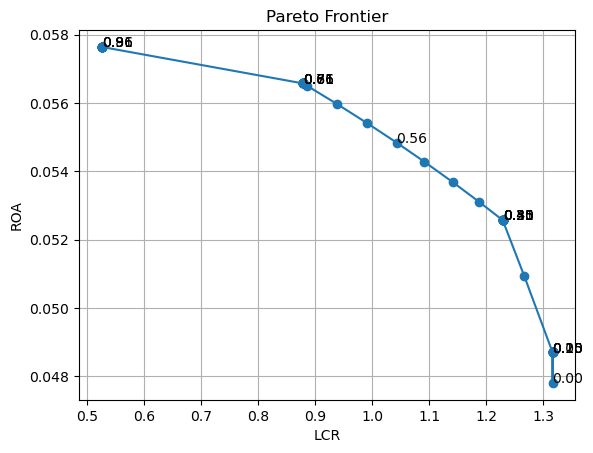

In [398]:
df_det = run_pareto(
    model_rep_state,
    roa_key="roa",
    lcr_key="lcr"
)

plt.figure()
plot_pareto(df_det, show_alpha = True)

plt.xlabel("LCR")
plt.ylabel("ROA")
plt.title("Pareto Frontier")

plt.grid()
plt.show()

#### Stochastic

In [400]:
model_rep_state_stochastic = build_model_stochastic(rep_state, config)

res = model_rep_state_stochastic["optimize"](0.5)
w = res.x

print("Weights:", w)
print("Expected ROA:", model_rep_state_stochastic["expected_roa"](w))
print("Expected LCR:", model_rep_state_stochastic["expected_lcr"](w))
print("Worst LCR:", model_rep_state_stochastic["worst_lcr"](w))
print("P(LCR < 1):", model_rep_state_stochastic["prob_lcr_breach"](w))

Weights: [0.02 0.2  0.3  0.16 0.02 0.3 ]
Expected ROA: 0.05274529559652309
Expected LCR: 1.239476740915714
Worst LCR: 1.05484367359183
P(LCR < 1): 0.005


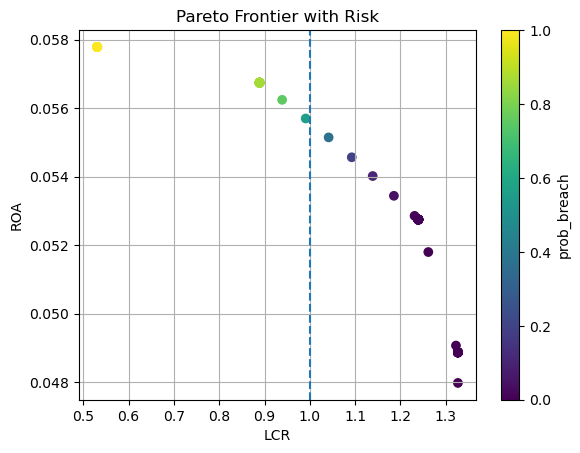

In [401]:
df_stoch = run_pareto(
    model_rep_state_stochastic,
    roa_key="expected_roa",
    lcr_key="expected_lcr",
    include_prob=True
)

plt.figure()

plot_pareto(
    df_stoch,
    label="Stochastic",
    color_by="prob_breach"
)

plt.axvline(x=1, linestyle='--')

plt.xlabel("LCR")
plt.ylabel("ROA")
plt.title("Pareto Frontier with Risk")

plt.grid()
plt.show()

### Current market state

State variables = Snap shot of the latest observation

#### Deterministic

In [404]:
current_df = df[
    (df["year"] == 2025) & (df["month"] == 12)
]

current_state = build_full_state(current_df, df)

current_state_report = extract_baseline_report(current_state, config)

print("Weights:", current_state_report["weights"])
print("HQLA:", current_state_report["HQLA"])
print("Outflows:", current_state_report["outflows"])
print("Inflows:", current_state_report["inflows"])
print("LCR:", current_state_report["LCR"])
print("Return:", current_state_report["return"])

Weights: [0.08569935 0.3268307  0.19346173 0.01015602 0.02954738 0.35430482]
HQLA: 1151098.4712999999
Outflows: 1821490.013
Inflows: 692072.8391499999
LCR: 1.0191968901766313
Return: 0.0470115181148723


In [405]:
model_current_state = build_model_deterministic(current_state)

In [406]:
res = model_current_state["optimize"](alpha=0.5)

w = res.x

print("Weights:", w)
print("ROA:", model_current_state["roa"](w))
print("LCR:", model_current_state["lcr"](w))

Weights: [0.02 0.2  0.3  0.16 0.02 0.3 ]
ROA: 0.052569220532531255
LCR: 1.212265958875495


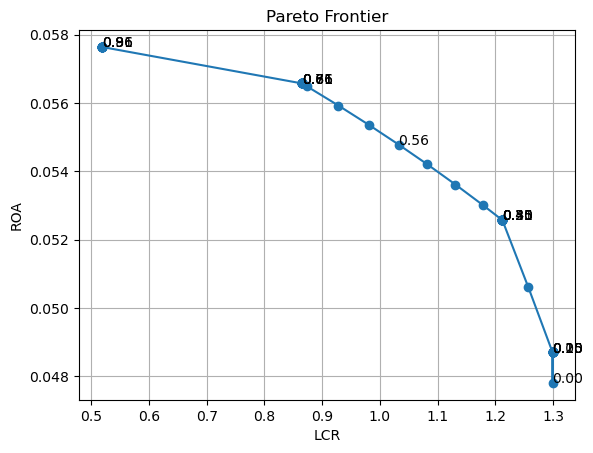

In [407]:
df_det = run_pareto(
    model_current_state,
    roa_key="roa",
    lcr_key="lcr"
)

plt.figure()
plot_pareto(df_det, show_alpha = True)

plt.xlabel("LCR")
plt.ylabel("ROA")
plt.title("Pareto Frontier")

plt.grid()
plt.show()

#### Stochastic

In [409]:
model_current_state_stochastic = build_model_stochastic(current_state, config)

res = model_current_state_stochastic["optimize"](0.5)
w = res.x

print("Weights:", w)
print("Expected ROA:", model_current_state_stochastic["expected_roa"](w))
print("Expected LCR:", model_current_state_stochastic["expected_lcr"](w))
print("Worst LCR:", model_current_state_stochastic["worst_lcr"](w))
print("P(LCR < 1):", model_current_state_stochastic["prob_lcr_breach"](w))

Weights: [0.02 0.2  0.3  0.16 0.02 0.3 ]
Expected ROA: 0.05184330724780615
Expected LCR: 1.2200263106272822
Worst LCR: 1.0691412039424746
P(LCR < 1): 0.003


/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


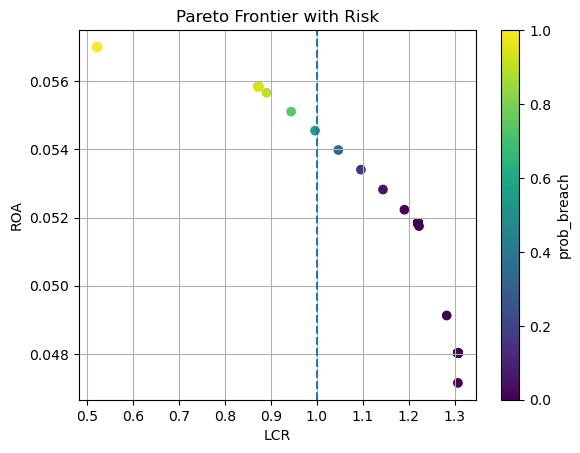

In [410]:
df_stoch = run_pareto(
    model_current_state_stochastic,
    roa_key="expected_roa",
    lcr_key="expected_lcr",
    include_prob=True
)

plt.figure()

plot_pareto(
    df_stoch,
    label="Stochastic",
    color_by="prob_breach"
)

plt.axvline(x=1, linestyle='--')

plt.xlabel("LCR")
plt.ylabel("ROA")
plt.title("Pareto Frontier with Risk")

plt.grid()
plt.show()

### Financial crisis (2007 - 2009)

#### Deterministic

In [413]:
crisis_0809_df = df[
    (df["year"] >= 2007) & (df["year"] <= 2009)
]

crisis_state = build_full_state(crisis_0809_df, crisis_0809_df)

crisis_state_report = extract_baseline_report(crisis_state, config)

print("Weights:", crisis_state_report["weights"])
print("HQLA:", crisis_state_report["HQLA"])
print("Outflows:", crisis_state_report["outflows"])
print("Inflows:", crisis_state_report["inflows"])
print("LCR:", crisis_state_report["LCR"])
print("Return:", crisis_state_report["return"])

Weights: [0.03981645 0.27199632 0.12476664 0.0046705  0.02366493 0.53508516]
HQLA: 164551.6197222222
Outflows: 452875.06212500005
Inflows: 163005.22978888892
LCR: 0.5676741811870254
Return: 0.06856868545930393


In [414]:
model_crisis_state = build_model_deterministic(crisis_state)

In [415]:
res = model_crisis_state["optimize"](alpha=0.5)

w = res.x

print("Weights:", w)
print("ROA:", model_crisis_state["roa"](w))
print("LCR:", model_crisis_state["lcr"](w))

Weights: [0.02 0.2  0.3  0.16 0.02 0.3 ]
ROA: 0.06729644646462227
LCR: 1.1726546093389012


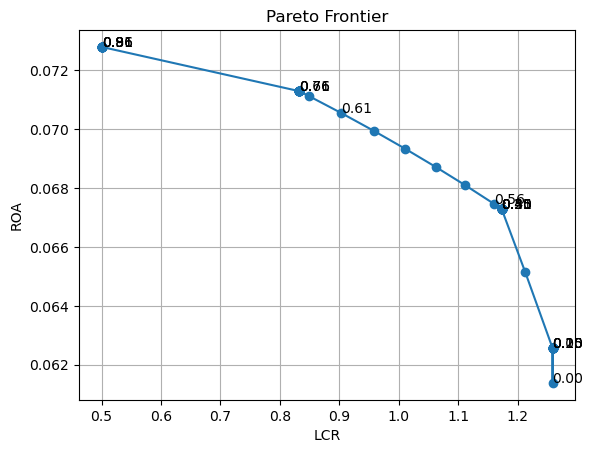

In [416]:
df_det = run_pareto(
    model_crisis_state,
    roa_key="roa",
    lcr_key="lcr"
)

plt.figure()
plot_pareto(df_det, show_alpha = True)

plt.xlabel("LCR")
plt.ylabel("ROA")
plt.title("Pareto Frontier")

plt.grid()
plt.show()

#### Stochastic

In [418]:
model_crisis_state_stochastic = build_model_stochastic(crisis_state, config)

res = model_crisis_state_stochastic["optimize"](0.5)
w = res.x

print("Weights:", w)
print("Expected ROA:", model_crisis_state_stochastic["expected_roa"](w))
print("Expected LCR:", model_crisis_state_stochastic["expected_lcr"](w))
print("Worst LCR:", model_crisis_state_stochastic["worst_lcr"](w))
print("P(LCR < 1):", model_crisis_state_stochastic["prob_lcr_breach"](w))

Weights: [0.02 0.2  0.3  0.16 0.02 0.3 ]
Expected ROA: 0.06729825579615183
Expected LCR: 1.1862521089714824
Worst LCR: 0.9917833172851962
P(LCR < 1): 0.062


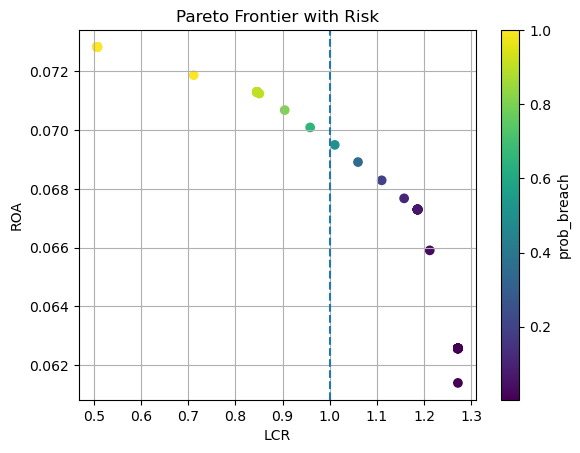

In [419]:
df_stoch = run_pareto(
    model_crisis_state_stochastic,
    roa_key="expected_roa",
    lcr_key="expected_lcr",
    include_prob=True
)

plt.figure()

plot_pareto(
    df_stoch,
    label="Stochastic",
    color_by="prob_breach"
)

plt.axvline(x=1, linestyle='--')

plt.xlabel("LCR")
plt.ylabel("ROA")
plt.title("Pareto Frontier with Risk")

plt.grid()
plt.show()

### COVID crisis (2019-2021)

#### Deterministic

In [422]:
crisis_covid_df = df[
    (df["year"] >= 2019) & (df["year"] <= 2021)
]

covid_state = build_full_state(crisis_covid_df, crisis_covid_df)

covid_state_report = extract_baseline_report(covid_state, config)

print("Weights:", covid_state_report["weights"])
print("HQLA:", covid_state_report["HQLA"])
print("Outflows:", covid_state_report["outflows"])
print("Inflows:", covid_state_report["inflows"])
print("LCR:", covid_state_report["LCR"])
print("Return:", covid_state_report["return"])

Weights: [0.03275991 0.25696578 0.17200665 0.02142814 0.03482118 0.48201834]
HQLA: 541142.2595472223
Outflows: 1123835.5241583334
Inflows: 402317.1084694445
LCR: 0.7500047785066614
Return: 0.026806573673882457


In [423]:
model_covid_state = build_model_deterministic(covid_state)

/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


In [424]:
res = model_covid_state["optimize"](alpha=0.5)

w = res.x

print("Weights:", w)
print("ROA:", model_covid_state["roa"](w))
print("LCR:", model_covid_state["lcr"](w))

Weights: [0.02       0.2        0.13889912 0.32110088 0.02       0.3       ]
ROA: 0.029766980564498332
LCR: 0.9690309895085855


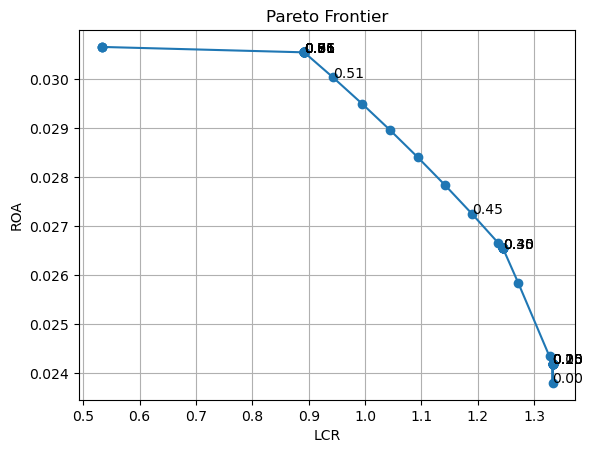

In [425]:
df_det = run_pareto(
    model_covid_state,
    roa_key="roa",
    lcr_key="lcr"
)

plt.figure()
plot_pareto(df_det, show_alpha = True)

plt.xlabel("LCR")
plt.ylabel("ROA")
plt.title("Pareto Frontier")

plt.grid()
plt.show()

#### Stochastic

In [427]:
model_covid_state_stochastic = build_model_stochastic(covid_state, config)

res = model_covid_state_stochastic["optimize"](0.5)
w = res.x

print("Weights:", w)
print("Expected ROA:", model_covid_state_stochastic["expected_roa"](w))
print("Expected LCR:", model_covid_state_stochastic["expected_lcr"](w))
print("Worst LCR:", model_covid_state_stochastic["worst_lcr"](w))
print("P(LCR < 1):", model_covid_state_stochastic["prob_lcr_breach"](w))

Weights: [0.02       0.2        0.13669073 0.32330927 0.02       0.3       ]
Expected ROA: 0.03002918178355491
Expected LCR: 0.9720742641182921
Worst LCR: 0.8457206724297006
P(LCR < 1): 0.651


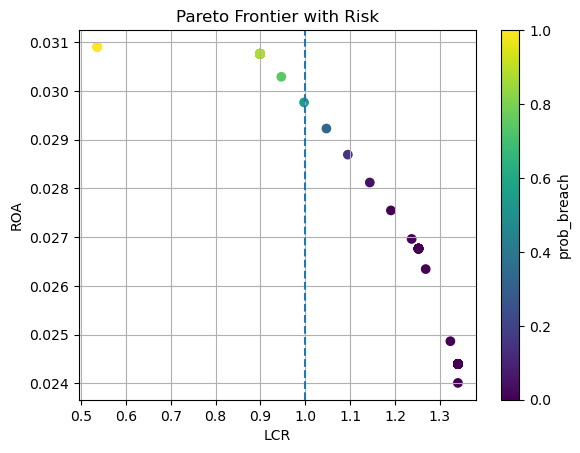

In [428]:
df_stoch = run_pareto(
    model_covid_state_stochastic,
    roa_key="expected_roa",
    lcr_key="expected_lcr",
    include_prob=True
)

plt.figure()

plot_pareto(
    df_stoch,
    label="Stochastic",
    color_by="prob_breach"
)

plt.axvline(x=1, linestyle='--')

plt.xlabel("LCR")
plt.ylabel("ROA")
plt.title("Pareto Frontier with Risk")

plt.grid()
plt.show()